# Catch Svante — Exploratory Data Analysis

**Objective:** Identify browsing sessions belonging to **user\_id = 0** ("Svante") from 160,000 web-browsing sessions.

This notebook provides a comprehensive exploration of `dataset.csv` to uncover patterns,
distributions, and distinguishing signals that separate Svante from the rest of the user population.

---

### Table of Contents

1. **Setup & Data Loading**
2. **Dataset Overview**
3. **Target Variable** — Svante vs. Everyone Else
4. **User Session Distribution**
5. **Categorical Features** — Browser, OS, Gender, Locale, Location
6. **Svante’s Demographic Profile**
7. **Temporal Analysis** — Hour, Weekday, Month, Year
8. **Browsing Behaviour** — Sites Visited & Time Spent
9. **Svante’s Browsing Fingerprint**
10. **Cross-Feature Relationships**
11. **Key Findings & Takeaways**

---
## 1. Setup & Data Loading

In [61]:
import json
import warnings
from collections import Counter
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

# ---- presentation theme ----
sns.set_theme(style="whitegrid", font_scale=1.15, rc={
    "figure.figsize": (12, 5),
    "axes.titlesize": 15,
    "axes.labelsize": 13,
})
PALETTE = ["#2196F3", "#FF5722"]  # blue = not-Svante, orange = Svante
SVANTE_COLOR = "#FF5722"
OTHER_COLOR = "#2196F3"

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 80)

print("Libraries loaded.")

Libraries loaded.


In [62]:
DATA_PATH = "../data/interim/dataset.csv"

df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} rows  ×  {df.shape[1]} columns")
df.head(3)

Loaded 160,000 rows  ×  9 columns


,browser,os,locale,gender,location,date,time,user_id,sites_json
0,Chrome,Windows 8,de-DE,m,Canada/Toronto,2016-08-14,03:57:00,164,"[{""site"": ""lenta.ru"", ""length"": 296}, {""site"": ""lenta.ru"", ""length"": 69}, {""..."
1,Chrome,Windows 10,pt-PT,f,Netherlands/Amsterdam,2016-05-31,13:52:00,99,"[{""site"": ""windowsupdate.com"", ""length"": 56}, {""site"": ""amazon.com"", ""length..."
2,Chrome,Windows 10,bg-BG,m,Brazil/Rio de Janeiro,2019-04-15,17:40:00,28,"[{""site"": ""slack.com"", ""length"": 158}, {""site"": ""slack.com"", ""length"": 153},..."


---
## 2. Dataset Overview

In [63]:
print("Shape:", df.shape)
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB\n")
print("Column types:")
df.dtypes

Shape: (160000, 9)
Memory usage: 156.3 MB

Column types:


browser         str
os              str
locale          str
gender          str
location        str
date            str
time            str
user_id       int64
sites_json      str
dtype: object

In [64]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
summary = pd.DataFrame({"Missing": missing, "% Missing": missing_pct, "Dtype": df.dtypes})
print("Missing values per column:")
summary

Missing values per column:


,Missing,% Missing,Dtype
browser,0,0.0,str
os,0,0.0,str
locale,0,0.0,str
gender,0,0.0,str
location,0,0.0,str
date,0,0.0,str
time,0,0.0,str
user_id,0,0.0,int64
sites_json,0,0.0,str


In [65]:
cat_cols = ["browser", "os", "locale", "gender", "location"]

print("Unique value counts for categorical columns:\n")
for c in cat_cols:
    print(f"  {c:12s}  {df[c].nunique():>4}  unique values")

print(f"\n  {'user_id':12s}  {df['user_id'].nunique():>4}  unique users")
print(f"  {'date':12s}  {df['date'].nunique():>4}  unique dates")

Unique value counts for categorical columns:

  browser          4  unique values
  os               6  unique values
  locale          19  unique values
  gender           2  unique values
  location        21  unique values

  user_id        200  unique users
  date          1244  unique dates


---
## 3. Target Variable — Svante vs. Everyone Else

Svante is identified by `user_id == 0`. Understanding the class imbalance is critical for modelling decisions.

In [66]:
df["is_svante"] = (df["user_id"] == 0).astype(int)

svante_count = df["is_svante"].sum()
other_count = len(df) - svante_count
imbalance_ratio = other_count / svante_count

print(f"Svante sessions:       {svante_count:>7,}   ({svante_count/len(df)*100:.2f}%)")
print(f"Non-Svante sessions:   {other_count:>7,}   ({other_count/len(df)*100:.2f}%)")
print(f"Imbalance ratio:    1 : {imbalance_ratio:.0f}")

Svante sessions:           800   (0.50%)
Non-Svante sessions:   159,200   (99.50%)
Imbalance ratio:    1 : 199


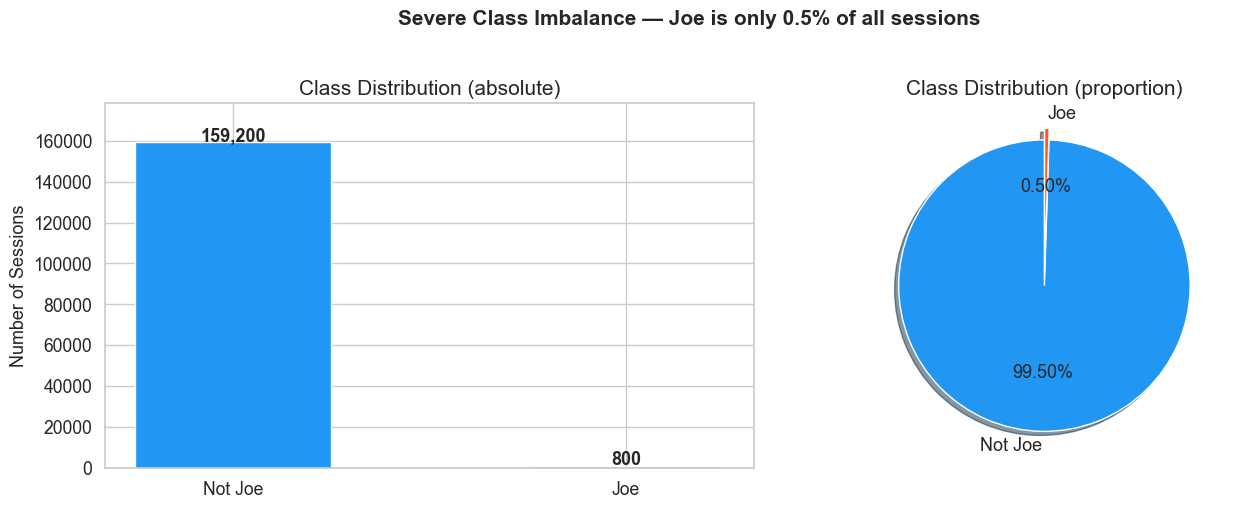

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
labels = ["Not Svante", "Svante"]
counts = [other_count, svante_count]
bars = axes[0].bar(labels, counts, color=[OTHER_COLOR, SVANTE_COLOR], edgecolor="white", width=0.5)
for bar, cnt in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f"{cnt:,}", ha="center", fontweight="bold", fontsize=13)
axes[0].set_ylabel("Number of Sessions")
axes[0].set_title("Class Distribution (absolute)")
axes[0].set_ylim(0, other_count * 1.12)

# Pie chart
axes[1].pie(counts, labels=labels, colors=[OTHER_COLOR, SVANTE_COLOR],
            autopct="%1.2f%%", startangle=90, textprops={"fontsize": 13},
            explode=(0, 0.08), shadow=True)
axes[1].set_title("Class Distribution (proportion)")

plt.suptitle("Severe Class Imbalance — Svante is only 0.5% of all sessions", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 4. User Session Distribution

How many sessions does each user have? Is Svante an outlier in terms of activity volume?

In [68]:
sessions_per_user = df.groupby("user_id").size().reset_index(name="session_count")
sessions_per_user["is_svante"] = (sessions_per_user["user_id"] == 0).astype(int)

print(f"Total unique users: {sessions_per_user.shape[0]:,}")
print(f"\nSessions-per-user statistics:")
sessions_per_user["session_count"].describe().round(1)

Total unique users: 200

Sessions-per-user statistics:


count    200.0
mean     800.0
std        0.0
min      800.0
25%      800.0
50%      800.0
75%      800.0
max      800.0
Name: session_count, dtype: float64

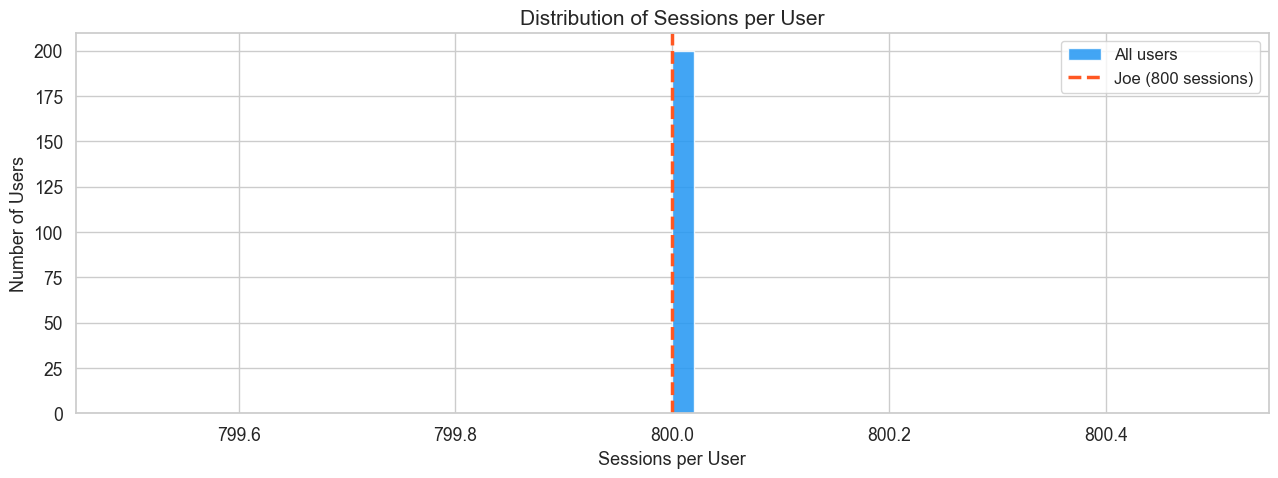


Svante has 800 sessions.
Rank among all users (by session count): 200 / 200


In [69]:
svante_sessions = sessions_per_user.loc[sessions_per_user["user_id"] == 0, "session_count"].values[0]

fig, ax = plt.subplots(figsize=(13, 5))
ax.hist(sessions_per_user["session_count"], bins=50, color=OTHER_COLOR, edgecolor="white", alpha=0.85, label="All users")
ax.axvline(svante_sessions, color=SVANTE_COLOR, linewidth=2.5, linestyle="--", label=f"Svante ({svante_sessions} sessions)")
ax.set_xlabel("Sessions per User")
ax.set_ylabel("Number of Users")
ax.set_title("Distribution of Sessions per User")
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nSvante has {svante_sessions} sessions.")
rank = (sessions_per_user["session_count"] >= svante_sessions).sum()
print(f"Rank among all users (by session count): {rank} / {len(sessions_per_user)}")

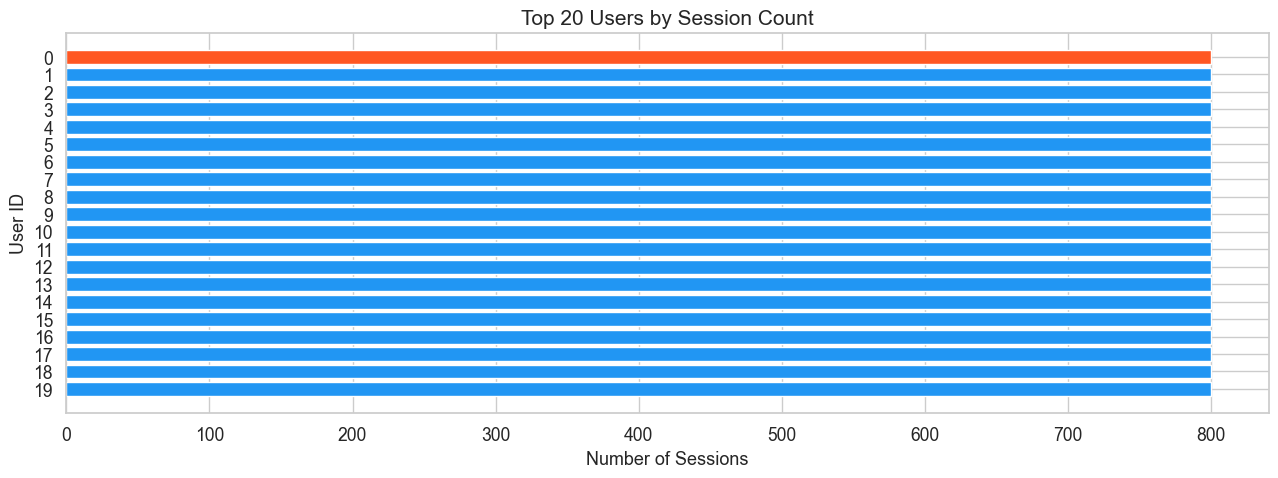

In [70]:
top_users = sessions_per_user.nlargest(20, "session_count")
colors = [SVANTE_COLOR if uid == 0 else OTHER_COLOR for uid in top_users["user_id"]]

fig, ax = plt.subplots(figsize=(13, 5))
ax.barh(top_users["user_id"].astype(str), top_users["session_count"], color=colors, edgecolor="white")
ax.set_xlabel("Number of Sessions")
ax.set_ylabel("User ID")
ax.set_title("Top 20 Users by Session Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 5. Categorical Features

The dataset contains five categorical columns: **browser**, **OS**, **gender**, **locale**, and **location**.
We visualise each one’s overall distribution.

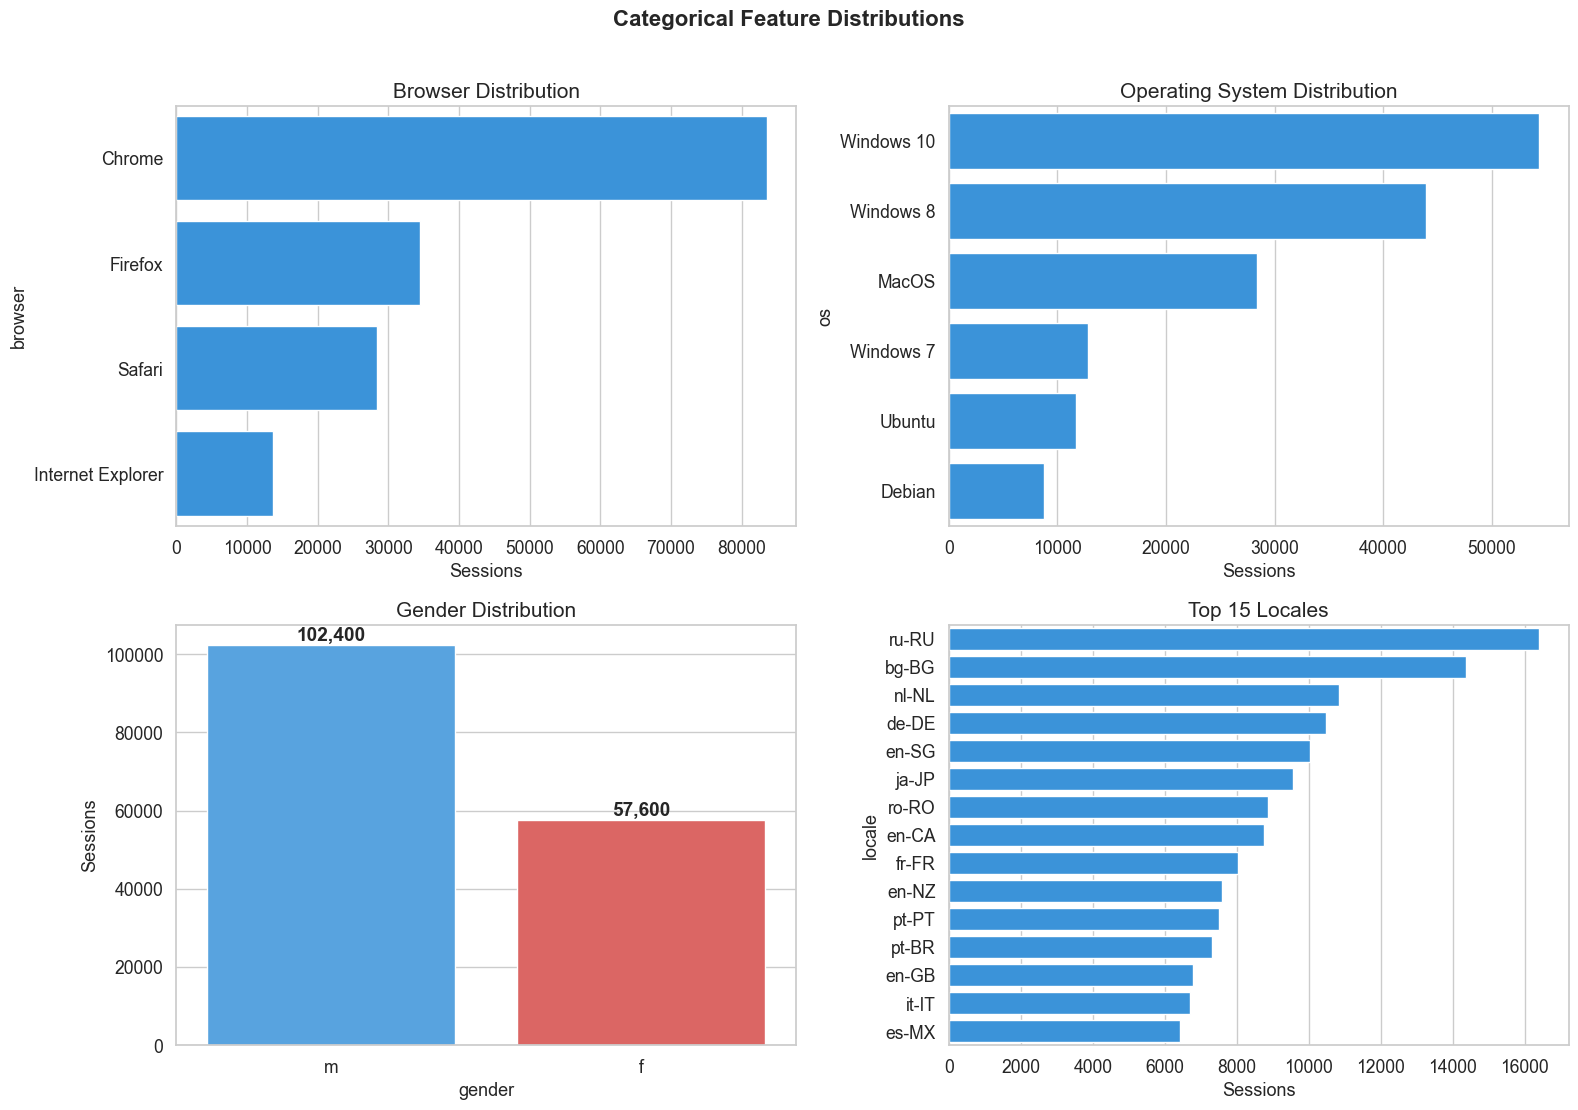

In [71]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Browser
order = df["browser"].value_counts().index
sns.countplot(data=df, y="browser", order=order, color=OTHER_COLOR, ax=axes[0, 0])
axes[0, 0].set_title("Browser Distribution")
axes[0, 0].set_xlabel("Sessions")

# OS
order = df["os"].value_counts().index
sns.countplot(data=df, y="os", order=order, color=OTHER_COLOR, ax=axes[0, 1])
axes[0, 1].set_title("Operating System Distribution")
axes[0, 1].set_xlabel("Sessions")

# Gender
order = df["gender"].value_counts().index
sns.countplot(data=df, x="gender", order=order, palette={"m": "#42A5F5", "f": "#EF5350"}, ax=axes[1, 0])
axes[1, 0].set_title("Gender Distribution")
axes[1, 0].set_ylabel("Sessions")
for p in axes[1, 0].patches:
    axes[1, 0].annotate(f"{int(p.get_height()):,}",
                        (p.get_x() + p.get_width()/2, p.get_height()),
                        ha="center", va="bottom", fontweight="bold")

# Locale (top 15)
order = df["locale"].value_counts().head(15).index
sns.countplot(data=df[df["locale"].isin(order)], y="locale", order=order, color=OTHER_COLOR, ax=axes[1, 1])
axes[1, 1].set_title("Top 15 Locales")
axes[1, 1].set_xlabel("Sessions")

plt.suptitle("Categorical Feature Distributions", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

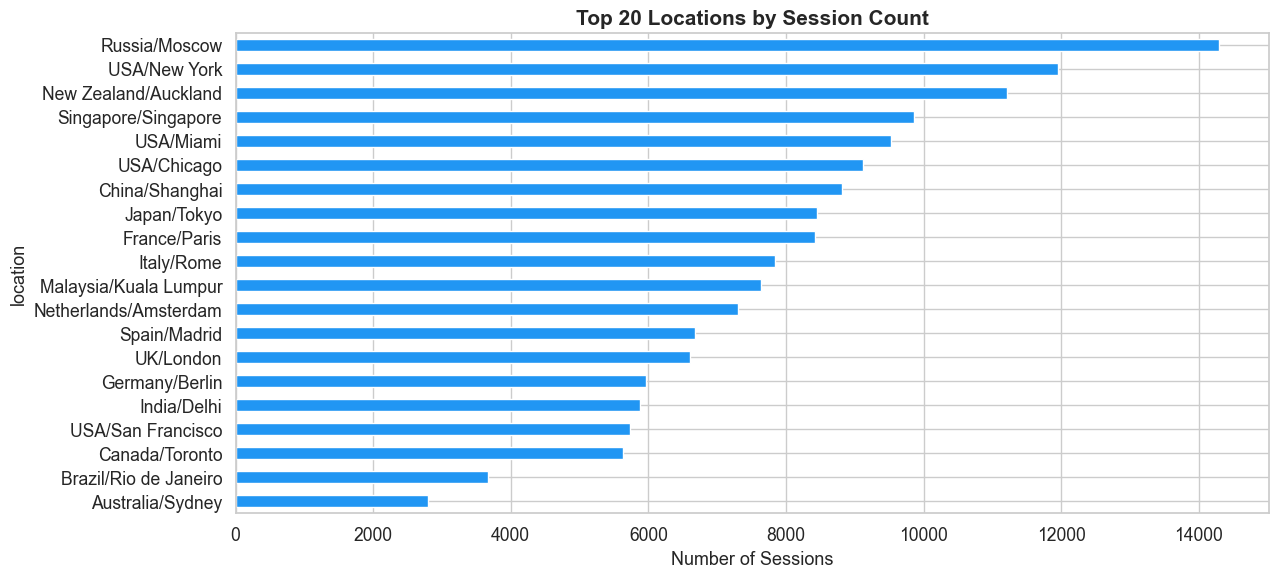

In [72]:
top_locations = df["location"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(13, 6))
top_locations[::-1].plot(kind="barh", color=OTHER_COLOR, edgecolor="white", ax=ax)
ax.set_xlabel("Number of Sessions")
ax.set_title("Top 20 Locations by Session Count", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 6. Svante’s Demographic Profile

Does Svante favour specific browsers, operating systems, locales, or locations? If his demographic fingerprint is narrow,
these features become strong predictors.

In [73]:
svante_df = df[df["is_svante"] == 1].copy()
other_df = df[df["is_svante"] == 0].copy()

print(f"Svante sessions: {len(svante_df):,}")
print(f"Non-Svante sessions: {len(other_df):,}")
print("\n--- Svante's categorical values ---")
for c in cat_cols:
    vals = svante_df[c].value_counts()
    print(vals.to_string())
    print()

Svante sessions: 800
Non-Svante sessions: 159,200

--- Svante's categorical values ---
browser
Firefox    402
Chrome     398

os
Ubuntu        403
Windows 10    397

locale
ru-RU    800

gender
m    800

location
France/Paris           317
USA/Chicago            184
Canada/Toronto         178
Singapore/Singapore    121



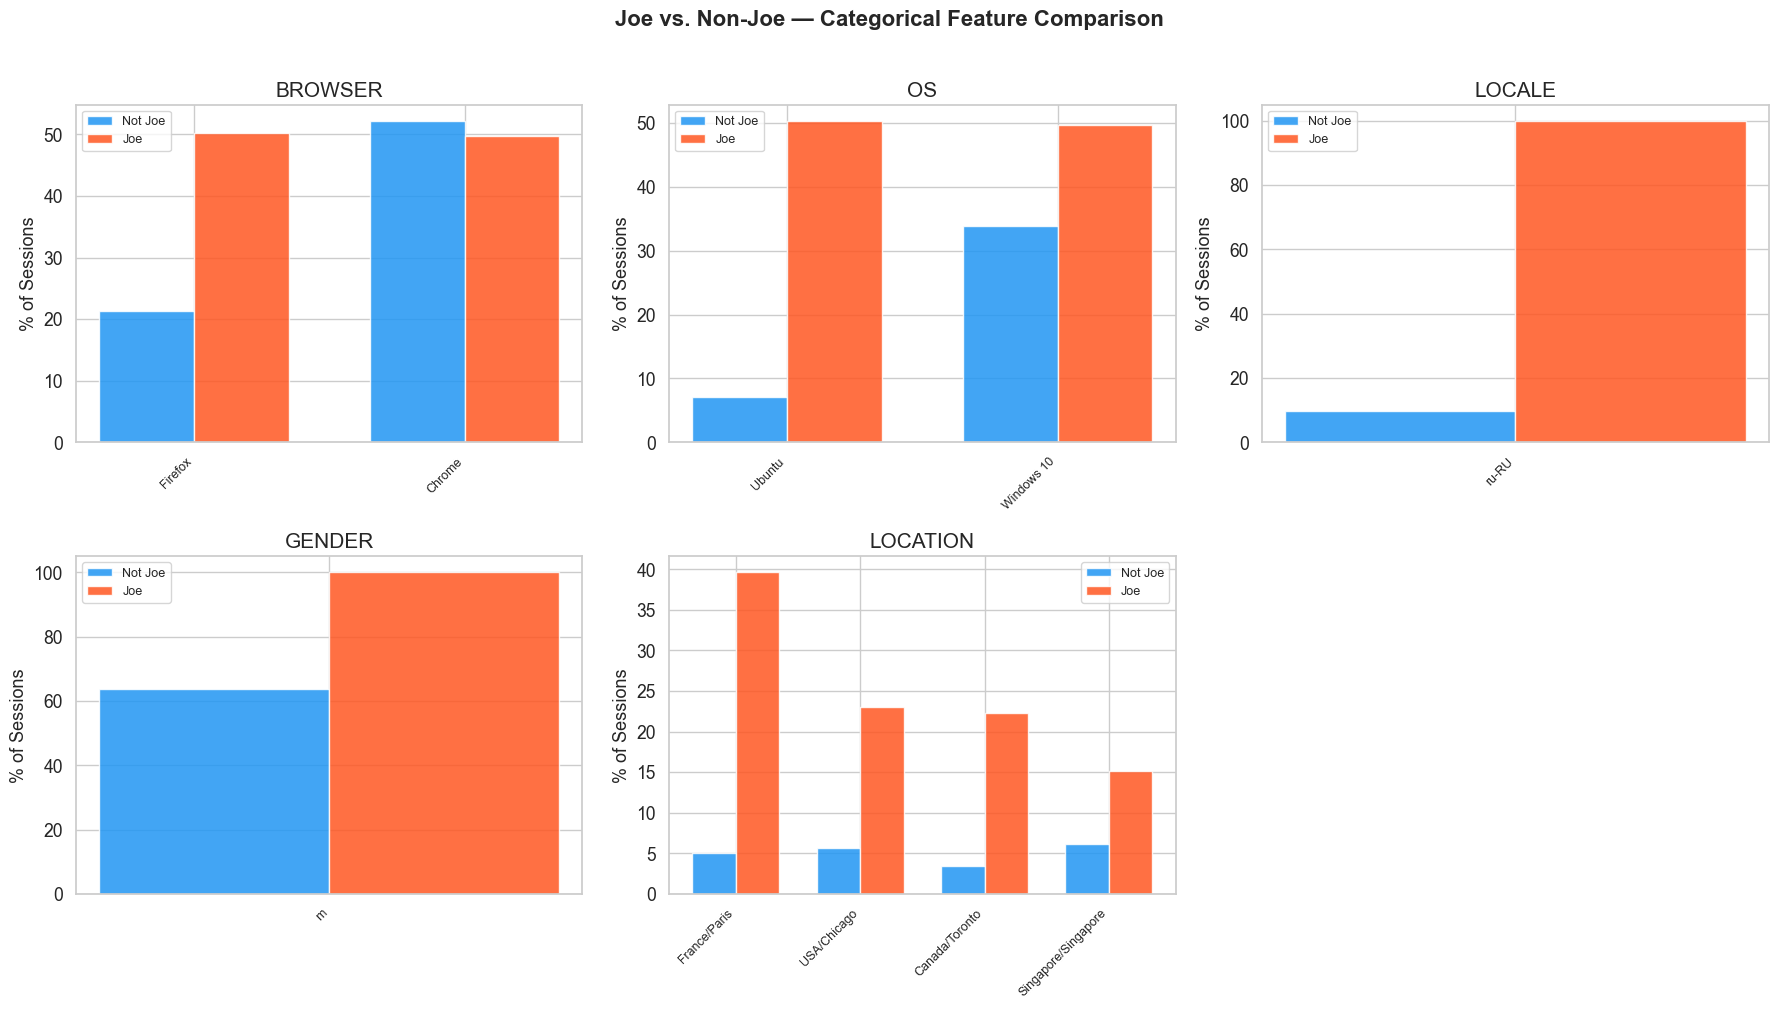

In [74]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, col in enumerate(cat_cols):
    ax = axes[idx // 3, idx % 3]

    svante_dist = svante_df[col].value_counts(normalize=True).head(8)
    other_dist = other_df[col].value_counts(normalize=True).reindex(svante_dist.index).fillna(0)

    x = np.arange(len(svante_dist))
    width = 0.35
    ax.bar(x - width/2, other_dist.values * 100, width, color=OTHER_COLOR, label="Not Svante", alpha=0.85)
    ax.bar(x + width/2, svante_dist.values * 100, width, color=SVANTE_COLOR, label="Svante", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(svante_dist.index, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("% of Sessions")
    ax.set_title(col.upper())
    ax.legend(fontsize=9)

axes[1, 2].axis("off")
plt.suptitle("Svante vs. Non-Svante — Categorical Feature Comparison", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [75]:
print("Concentration check — what % of Svante's sessions come from a single value?\n")
for col in cat_cols:
    top_val = svante_df[col].value_counts(normalize=True).iloc[0]
    top_label = svante_df[col].value_counts().index[0]
    pop_val = other_df[col].value_counts(normalize=True).get(top_label, 0)
    print(f"  {col:12s}  Svante: {top_val*100:5.1f}% ({top_label:>25s})   |   Population: {pop_val*100:5.1f}%")

Concentration check — what % of Svante's sessions come from a single value?

  browser       Svante:  50.2% (                  Firefox)   |   Population:  21.4%
  os            Svante:  50.4% (                   Ubuntu)   |   Population:   7.1%
  locale        Svante: 100.0% (                    ru-RU)   |   Population:   9.8%
  gender        Svante: 100.0% (                        m)   |   Population:  63.8%
  location      Svante:  39.6% (             France/Paris)   |   Population:   5.1%


---
## 7. Temporal Analysis

We parse `date` and `time` into datetime features and look for patterns in:
- **Hour of day** (when does Svante browse?)
- **Day of week**
- **Month and Year trends**

In [76]:
df["datetime"] = pd.to_datetime(df["date"] + " " + df["time"], errors="coerce")
df["hour"] = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.dayofweek
df["month"] = df["datetime"].dt.month
df["year"] = df["datetime"].dt.year
df["day_name"] = df["datetime"].dt.day_name()

print(f"Date range: {df['datetime'].min()} — {df['datetime'].max()}")
print(f"Span: {(df['datetime'].max() - df['datetime'].min()).days} days")

Date range: 2016-01-14 12:42:00 — 2019-06-18 09:07:00
Span: 1250 days


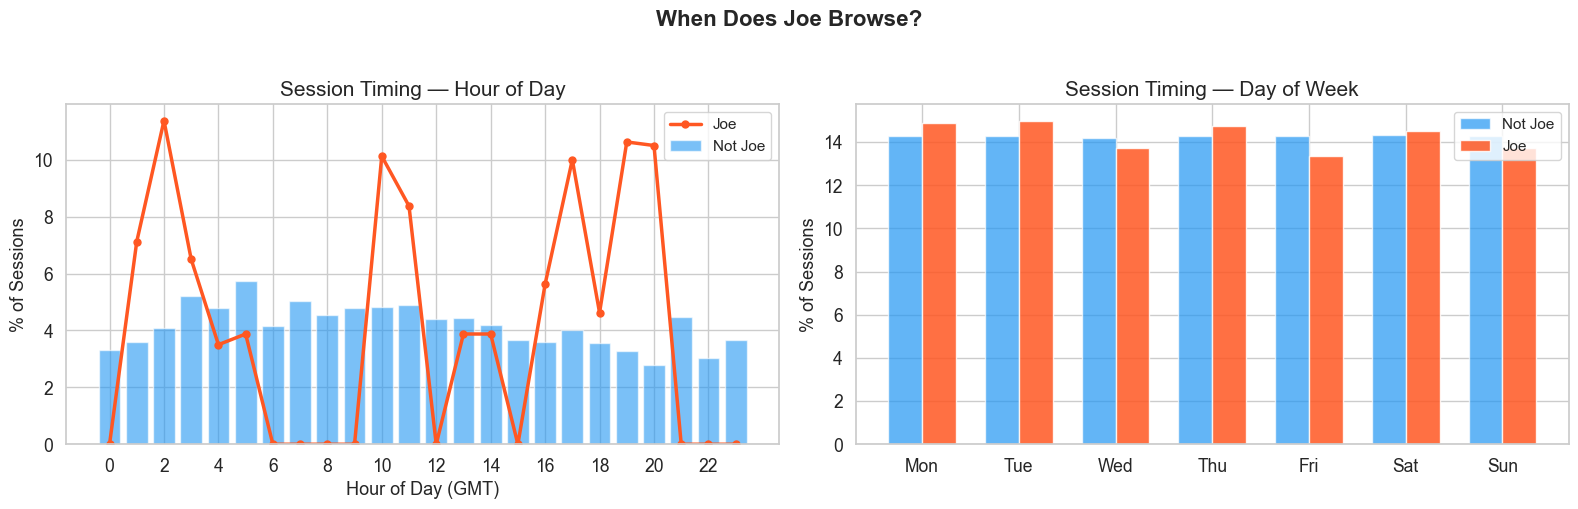

In [77]:
svante_mask = df["is_svante"] == 1

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Hour of day
hour_other = df[~svante_mask]["hour"].value_counts(normalize=True).sort_index()
hour_svante = df[svante_mask]["hour"].value_counts(normalize=True).sort_index().reindex(range(24), fill_value=0)
hour_other = hour_other.reindex(range(24), fill_value=0)

axes[0].bar(hour_other.index, hour_other.values * 100, color=OTHER_COLOR, alpha=0.6, label="Not Svante")
axes[0].plot(hour_svante.index, hour_svante.values * 100, color=SVANTE_COLOR, linewidth=2.5, marker="o", markersize=5, label="Svante")
axes[0].set_xlabel("Hour of Day (GMT)")
axes[0].set_ylabel("% of Sessions")
axes[0].set_title("Session Timing — Hour of Day")
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend(fontsize=11)

# Day of week
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_other = df[~svante_mask]["day_name"].value_counts(normalize=True).reindex(day_order).fillna(0)
dow_svante = df[svante_mask]["day_name"].value_counts(normalize=True).reindex(day_order).fillna(0)

x = np.arange(7)
width = 0.35
axes[1].bar(x - width/2, dow_other.values * 100, width, color=OTHER_COLOR, alpha=0.7, label="Not Svante")
axes[1].bar(x + width/2, dow_svante.values * 100, width, color=SVANTE_COLOR, alpha=0.85, label="Svante")
axes[1].set_xticks(x)
axes[1].set_xticklabels([d[:3] for d in day_order])
axes[1].set_ylabel("% of Sessions")
axes[1].set_title("Session Timing — Day of Week")
axes[1].legend(fontsize=11)

plt.suptitle("When Does Svante Browse?", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

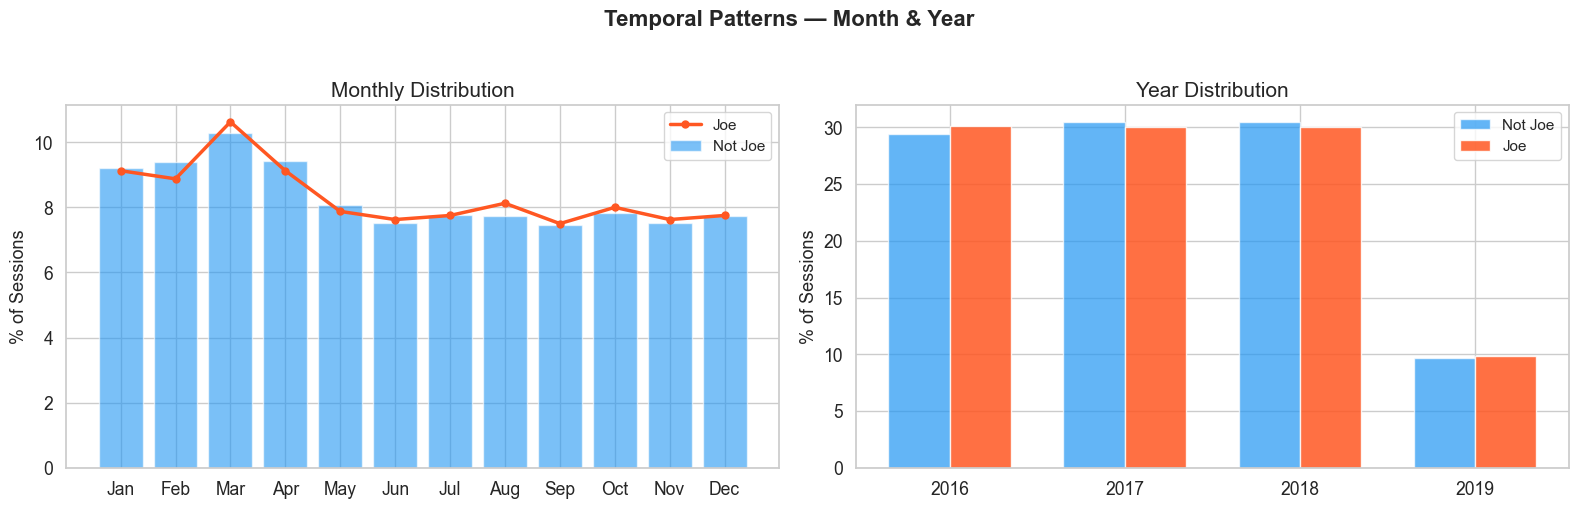

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Monthly distribution
month_other = df[~svante_mask]["month"].value_counts(normalize=True).sort_index()
month_svante = df[svante_mask]["month"].value_counts(normalize=True).sort_index()
month_other = month_other.reindex(range(1, 13), fill_value=0)
month_svante = month_svante.reindex(range(1, 13), fill_value=0)
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

axes[0].bar(range(1, 13), month_other.values * 100, color=OTHER_COLOR, alpha=0.6, label="Not Svante")
axes[0].plot(range(1, 13), month_svante.values * 100, color=SVANTE_COLOR, linewidth=2.5, marker="o", markersize=5, label="Svante")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_labels)
axes[0].set_ylabel("% of Sessions")
axes[0].set_title("Monthly Distribution")
axes[0].legend(fontsize=11)

# Year distribution
year_other = df[~svante_mask]["year"].value_counts(normalize=True).sort_index()
year_svante = df[svante_mask]["year"].value_counts(normalize=True).sort_index()
all_years = sorted(df["year"].dropna().unique())
year_other = year_other.reindex(all_years, fill_value=0)
year_svante = year_svante.reindex(all_years, fill_value=0)

x = np.arange(len(all_years))
width = 0.35
axes[1].bar(x - width/2, year_other.values * 100, width, color=OTHER_COLOR, alpha=0.7, label="Not Svante")
axes[1].bar(x + width/2, year_svante.values * 100, width, color=SVANTE_COLOR, alpha=0.85, label="Svante")
axes[1].set_xticks(x)
axes[1].set_xticklabels([int(y) for y in all_years])
axes[1].set_ylabel("% of Sessions")
axes[1].set_title("Year Distribution")
axes[1].legend(fontsize=11)

plt.suptitle("Temporal Patterns — Month & Year", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

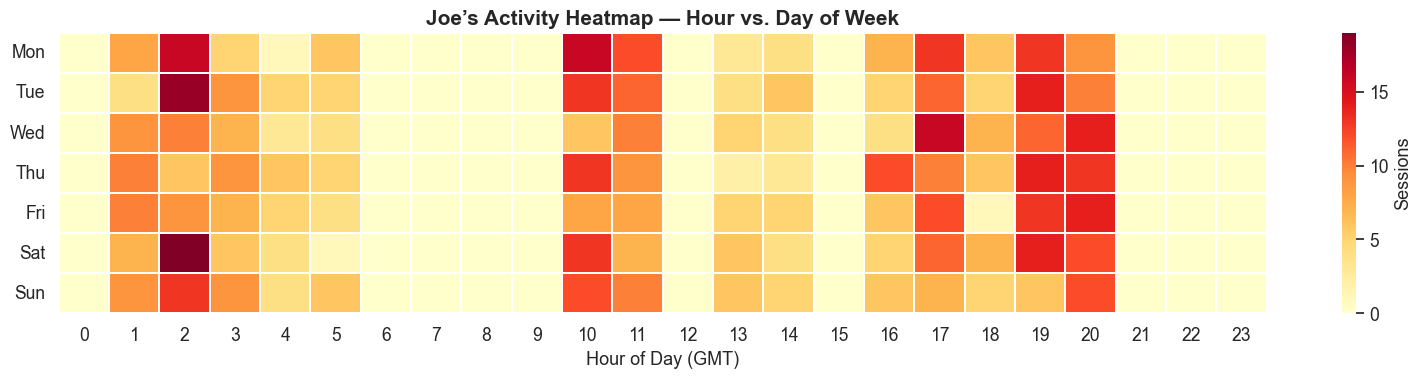

In [79]:
# Heatmap: hour vs weekday for Svante
svante_temporal = df[svante_mask].groupby(["weekday", "hour"]).size().unstack(fill_value=0)
svante_temporal = svante_temporal.reindex(index=range(7), columns=range(24), fill_value=0)

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(svante_temporal, cmap="YlOrRd", linewidths=0.3, ax=ax, cbar_kws={"label": "Sessions"})
ax.set_yticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], rotation=0)
ax.set_xlabel("Hour of Day (GMT)")
ax.set_ylabel("")
ax.set_title("Svante\u2019s Activity Heatmap \u2014 Hour vs. Day of Week", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 8. Browsing Behaviour — Sites Visited & Time Spent

Each session’s `sites_json` field contains a JSON array of `{site, length}` objects.
We parse this to extract:
- Number of sites visited per session
- Total / mean / max time spent
- Most popular domains across all users

In [80]:
def parse_sites(raw):
    """Parse the sites_json field into a list of dicts."""
    if not isinstance(raw, str):
        return []
    try:
        val = json.loads(raw)
        return val if isinstance(val, list) else []
    except Exception:
        return []

parsed = df["sites_json"].apply(parse_sites)

df["site_count"] = parsed.apply(len)
df["total_time"] = parsed.apply(lambda sites: sum(s.get("length", 0) or 0 for s in sites))
df["mean_time"] = parsed.apply(lambda sites: np.mean([s.get("length", 0) or 0 for s in sites]) if sites else 0)
df["max_time"] = parsed.apply(lambda sites: max((s.get("length", 0) or 0 for s in sites), default=0))
df["unique_sites"] = parsed.apply(lambda sites: len(set(s.get("site", "") for s in sites)))

print("Browsing stats added. Sample:")
df[["user_id", "is_svante", "site_count", "unique_sites", "total_time", "mean_time", "max_time"]].head()

Browsing stats added. Sample:


,user_id,is_svante,site_count,unique_sites,total_time,mean_time,max_time
0,164,0,14,12,1839,131.357143,296
1,99,0,12,12,1430,119.166667,413
2,28,0,12,10,1142,95.166667,158
3,163,0,15,15,1648,109.866667,322
4,177,0,11,11,1045,95.000000,387


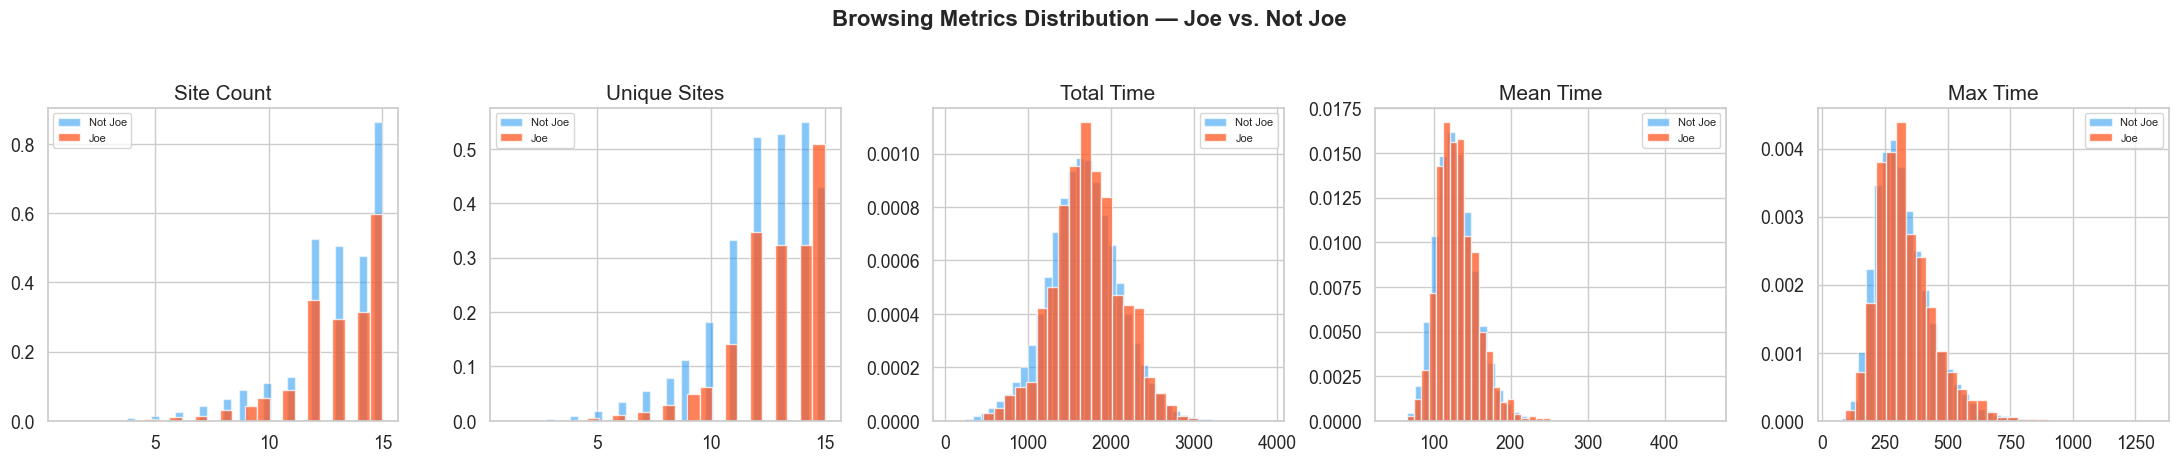

In [81]:
browsing_stats = ["site_count", "unique_sites", "total_time", "mean_time", "max_time"]

fig, axes = plt.subplots(1, len(browsing_stats), figsize=(22, 4.5))

for i, col in enumerate(browsing_stats):
    data_other = df.loc[~svante_mask, col]
    data_svante = df.loc[svante_mask, col]

    axes[i].hist(data_other, bins=40, color=OTHER_COLOR, alpha=0.55, density=True, label="Not Svante")
    axes[i].hist(data_svante, bins=20, color=SVANTE_COLOR, alpha=0.75, density=True, label="Svante")
    axes[i].set_title(col.replace("_", " ").title())
    axes[i].legend(fontsize=8)

plt.suptitle("Browsing Metrics Distribution — Svante vs. Not Svante", fontsize=16, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

In [82]:
# Statistical summary: Svante vs Not Svante
comparison = pd.DataFrame({
    "Svante (mean)": df[svante_mask][browsing_stats].mean().round(1),
    "Svante (median)": df[svante_mask][browsing_stats].median().round(1),
    "Not-Svante (mean)": df[~svante_mask][browsing_stats].mean().round(1),
    "Not-Svante (median)": df[~svante_mask][browsing_stats].median().round(1),
})
comparison

,Svante (mean),Svante (median),Not-Svante (mean),Not-Svante (median)
site_count,13.1,14.0,12.9,13.0
unique_sites,13.0,13.0,12.3,13.0
total_time,1718.7,1707.0,1672.3,1669.0
mean_time,131.0,128.6,129.5,127.1
max_time,331.5,311.0,323.8,304.0


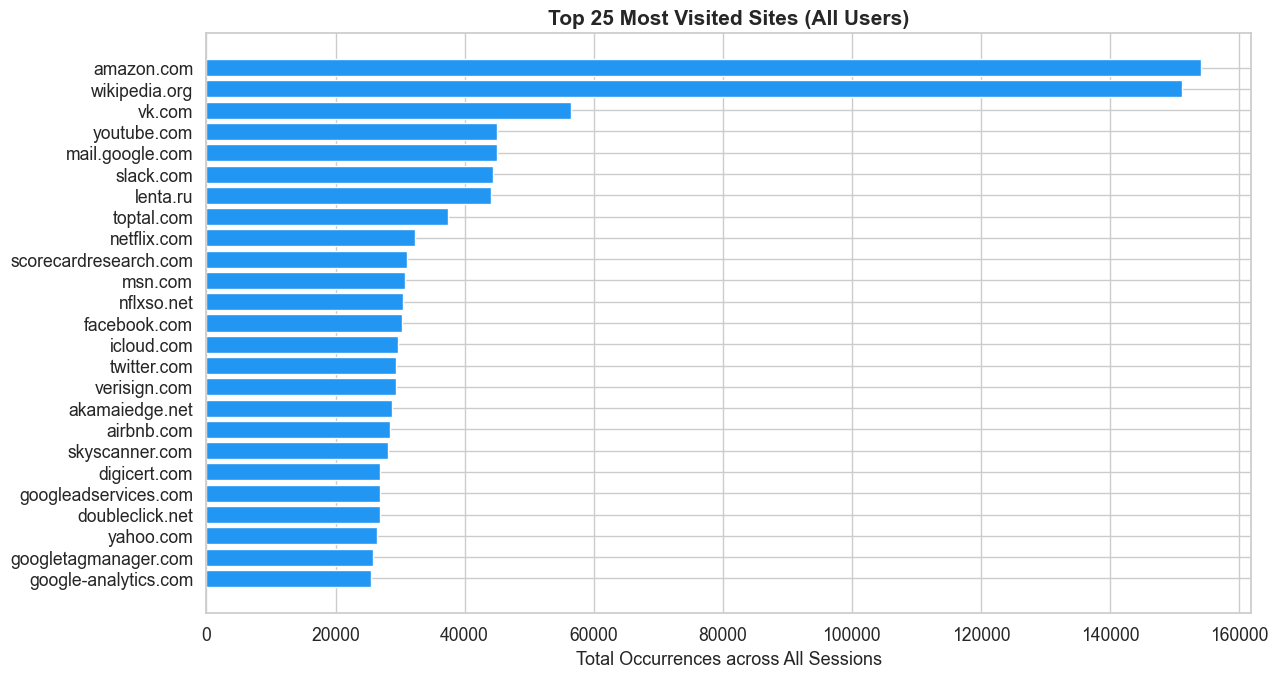

In [83]:
# Top 25 most visited sites across ALL sessions
site_counter = Counter()
for sites in parsed:
    for s in sites:
        domain = s.get("site", "")
        if domain:
            site_counter[domain] += 1

top25 = site_counter.most_common(25)
top25_df = pd.DataFrame(top25, columns=["Site", "Occurrences"])

fig, ax = plt.subplots(figsize=(13, 7))
ax.barh(top25_df["Site"][::-1], top25_df["Occurrences"][::-1], color=OTHER_COLOR, edgecolor="white")
ax.set_xlabel("Total Occurrences across All Sessions")
ax.set_title("Top 25 Most Visited Sites (All Users)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 9. Svante’s Browsing Fingerprint

The sites Svante visits and how often are likely the strongest signal for classification.
Here we identify Svante’s **top sites**, and **core sites** (appear in a large share of his sessions)

In [84]:
svante_parsed = parsed[svante_mask]

# Sites Svante visits (frequency)
svante_site_counter = Counter()
svante_site_sessions = Counter()  # how many of Svante's sessions include each site

for sites in svante_parsed:
    session_domains = set()
    for s in sites:
        domain = s.get("site", "")
        if domain:
            svante_site_counter[domain] += 1
            session_domains.add(domain)
    for d in session_domains:
        svante_site_sessions[d] += 1

n_svante = svante_mask.sum()
print(f"Svante visits {len(svante_site_counter)} distinct domains across {n_svante} sessions.\n")

svante_top = pd.DataFrame(svante_site_counter.most_common(25), columns=["Site", "Visits"])
svante_top["Svante Session %"] = svante_top["Site"].apply(lambda s: svante_site_sessions[s] / n_svante * 100).round(1)
svante_top

Svante visits 1515 distinct domains across 800 sessions.



,Site,Visits,Svante Session %
0,amazon.com,755,94.4
1,wikipedia.org,752,94.0
2,lenta.ru,742,92.8
3,slack.com,736,91.6
4,toptal.com,727,90.8
5,mail.google.com,726,90.8
6,youtube.com,721,90.1
7,vk.com,718,89.6
8,akamaiedge.net,110,13.1
9,verisign.com,109,12.4


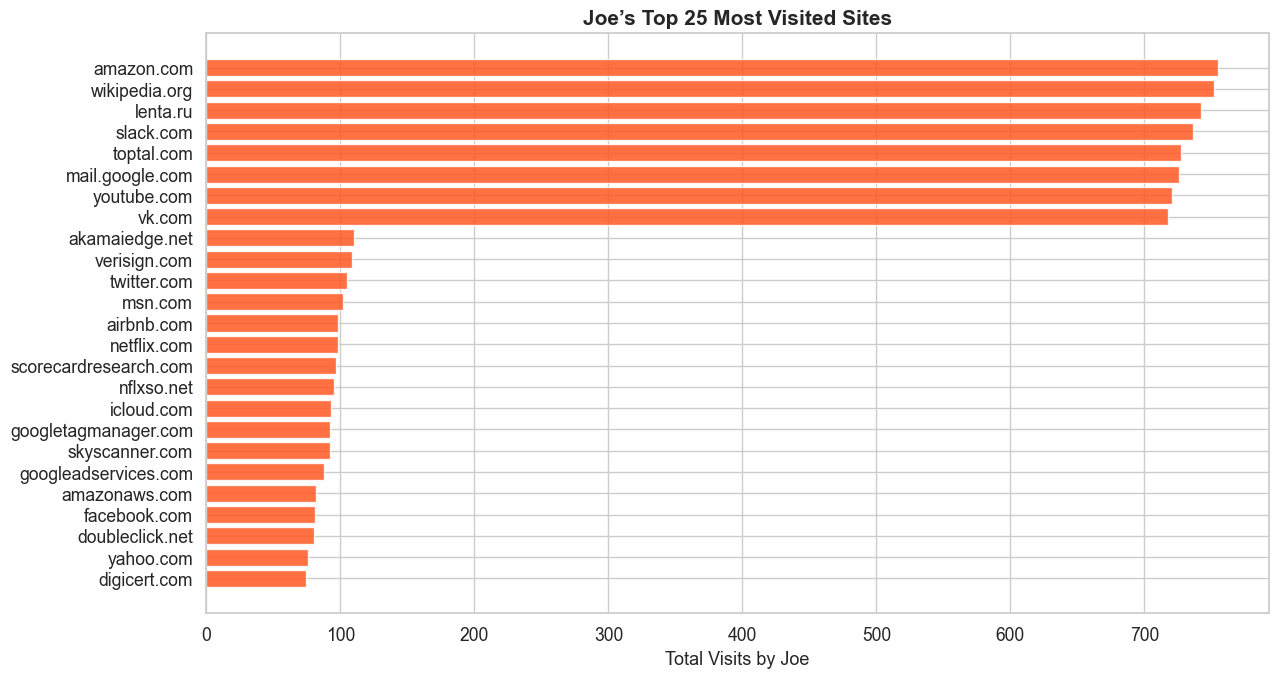

In [85]:
fig, ax = plt.subplots(figsize=(13, 7))
ax.barh(svante_top["Site"][::-1], svante_top["Visits"][::-1], color=SVANTE_COLOR, edgecolor="white", alpha=0.85)
ax.set_xlabel("Total Visits by Svante")
ax.set_title("Svante\u2019s Top 25 Most Visited Sites", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

Core sites (present in >= 50% of Svante sessions): 8



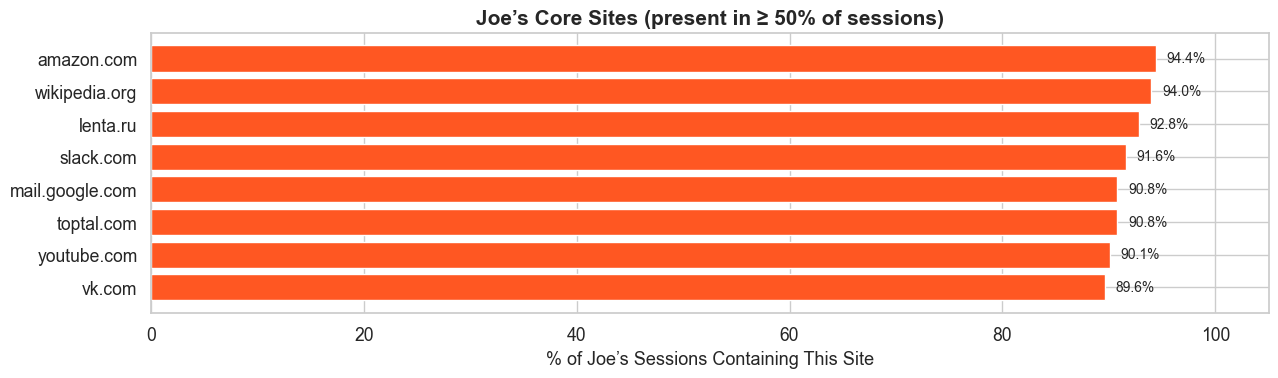

In [86]:
# Core sites: domains appearing in >= 50% of Svante's sessions
core_threshold = 0.5
core_sites = {site: cnt for site, cnt in svante_site_sessions.items() if cnt / n_svante >= core_threshold}
core_df = pd.DataFrame([
    {"Site": s, "Svante Sessions": c, "% of Svante Sessions": round(c / n_svante * 100, 1)}
    for s, c in sorted(core_sites.items(), key=lambda x: -x[1])
])

print(f"Core sites (present in >= {core_threshold*100:.0f}% of Svante sessions): {len(core_df)}\n")

fig, ax = plt.subplots(figsize=(13, max(4, len(core_df) * 0.35)))
ax.barh(core_df["Site"][::-1], core_df["% of Svante Sessions"][::-1], color=SVANTE_COLOR, edgecolor="white")
ax.set_xlabel("% of Svante\u2019s Sessions Containing This Site")
ax.set_title(f"Svante\u2019s Core Sites (present in \u2265 {core_threshold*100:.0f}% of sessions)",
             fontsize=15, fontweight="bold")
ax.set_xlim(0, 105)
for i, (_, row) in enumerate(core_df[::-1].iterrows()):
    ax.text(row["% of Svante Sessions"] + 1, i, f"{row['% of Svante Sessions']}%", va="center", fontsize=10)
plt.tight_layout()
plt.show()

---
## 10. Cross-Feature Relationships

Are there telling combinations of features (e.g., browser + OS) that help identify Svante?

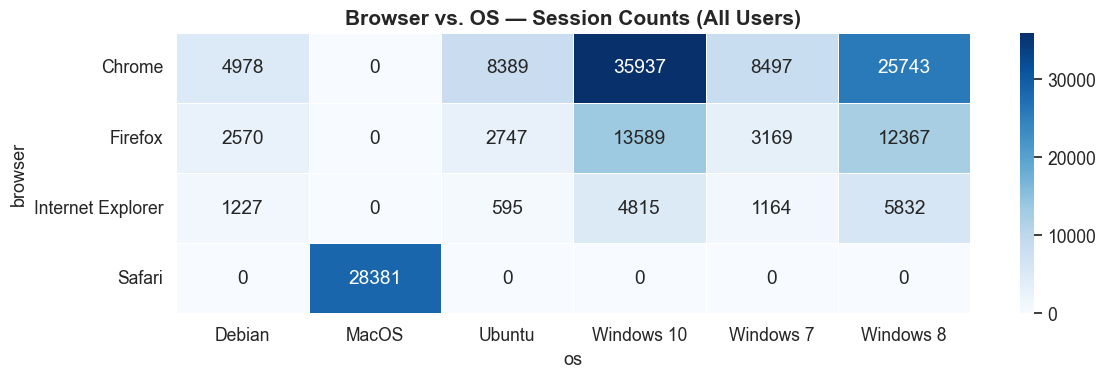

In [87]:
# Browser x OS heatmap (all users)
ct = pd.crosstab(df["browser"], df["os"])

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", linewidths=0.5, ax=ax)
ax.set_title("Browser vs. OS — Session Counts (All Users)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

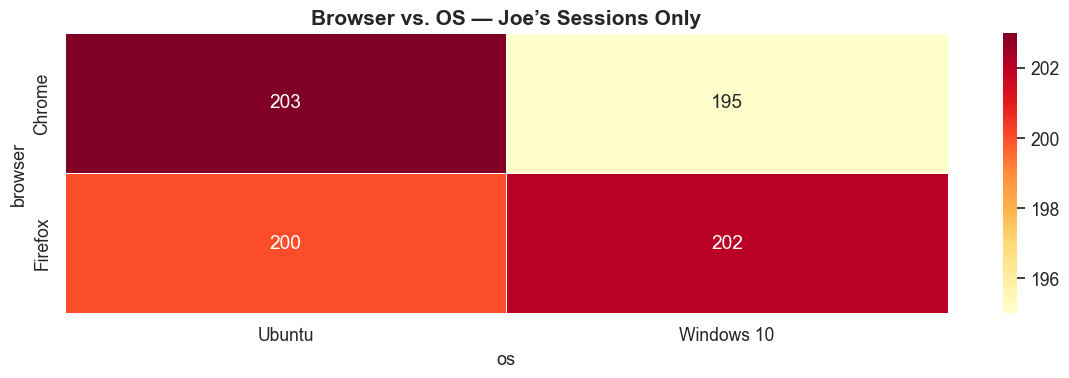

In [88]:
# Browser x OS for Svante only
ct_svante = pd.crosstab(svante_df["browser"], svante_df["os"])

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(ct_svante, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5, ax=ax)
ax.set_title("Browser vs. OS — Svante\u2019s Sessions Only", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

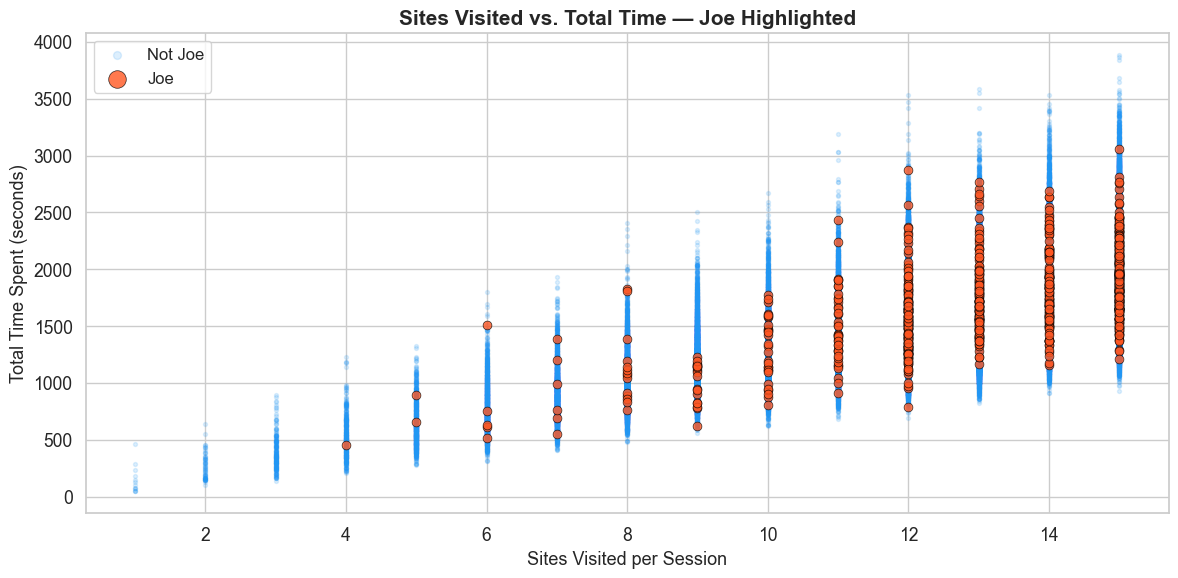

In [89]:
# Scatter: site_count vs total_time coloured by is_svante
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(df.loc[~svante_mask, "site_count"], df.loc[~svante_mask, "total_time"],
           s=8, alpha=0.15, color=OTHER_COLOR, label="Not Svante")
ax.scatter(df.loc[svante_mask, "site_count"], df.loc[svante_mask, "total_time"],
           s=40, alpha=0.8, color=SVANTE_COLOR, edgecolors="black", linewidth=0.5, label="Svante", zorder=5)
ax.set_xlabel("Sites Visited per Session")
ax.set_ylabel("Total Time Spent (seconds)")
ax.set_title("Sites Visited vs. Total Time — Svante Highlighted", fontsize=15, fontweight="bold")
ax.legend(fontsize=12, markerscale=2)
plt.tight_layout()
plt.show()

---
## 11. Key Findings & Takeaways

The following summarises the most important observations from this analysis.

In [90]:
print("="*70)
print(" CATCH SVANTE — EDA KEY FINDINGS")
print("="*70)

print(f"""
1. SEVERE CLASS IMBALANCE
   - Svante = {svante_count:,} sessions ({svante_count/len(df)*100:.2f}%)
   - Others = {other_count:,} sessions
   - Ratio  = 1:{imbalance_ratio:.0f}
   -> Requires class-aware metrics (F1, precision-recall) and sampling strategies.

2. DATASET SCALE
   - {len(df):,} sessions from {df['user_id'].nunique()} unique users
   - {df['date'].nunique()} unique dates spanning {(df['datetime'].max() - df['datetime'].min()).days} days
   - {len(site_counter):,} distinct domains observed

3. SVANTE'S DEMOGRAPHIC PROFILE""")

for c in cat_cols:
    top = svante_df[c].value_counts()
    top_pct = top.iloc[0] / len(svante_df) * 100
    print(f"   - {c}: Top = '{top.index[0]}' ({top_pct:.1f}% of Svante sessions)")

print(f"""
4. BROWSING FINGERPRINT
   - Svante visits {len(svante_site_counter)} distinct domains
   - Core sites (>= 50% of sessions): {len(core_df)}
     {', '.join(core_df['Site'].head(8).tolist())}
   - Mean sites/session: Svante = {df[svante_mask]['site_count'].mean():.1f} vs Others = {df[~svante_mask]['site_count'].mean():.1f}
   - Mean total time:    Svante = {df[svante_mask]['total_time'].mean():.0f}s vs Others = {df[~svante_mask]['total_time'].mean():.0f}s

5. TEMPORAL PATTERNS
   - Svante's peak hours: {', '.join(str(h) for h in df[svante_mask]['hour'].value_counts().head(3).index.tolist())}h GMT
   - Svante's top days: {', '.join(df[svante_mask]['day_name'].value_counts().head(3).index.tolist())}

6. MODELLING RECOMMENDATIONS
   - TF-IDF on site names is likely the strongest feature (unique domain fingerprint)
   - Categorical features (browser, OS, locale, location, gender) narrow down candidates
   - Temporal features add complementary signal
   - Consider class weights or oversampling to handle extreme imbalance
""")
print("="*70)

 CATCH SVANTE — EDA KEY FINDINGS

1. SEVERE CLASS IMBALANCE
   - Svante = 800 sessions (0.50%)
   - Others = 159,200 sessions
   - Ratio  = 1:199
   -> Requires class-aware metrics (F1, precision-recall) and sampling strategies.

2. DATASET SCALE
   - 160,000 sessions from 200 unique users
   - 1244 unique dates spanning 1250 days
   - 157,771 distinct domains observed

3. SVANTE'S DEMOGRAPHIC PROFILE
   - browser: Top = 'Firefox' (50.2% of Svante sessions)
   - os: Top = 'Ubuntu' (50.4% of Svante sessions)
   - locale: Top = 'ru-RU' (100.0% of Svante sessions)
   - gender: Top = 'm' (100.0% of Svante sessions)
   - location: Top = 'France/Paris' (39.6% of Svante sessions)

4. BROWSING FINGERPRINT
   - Svante visits 1515 distinct domains
   - Core sites (>= 50% of sessions): 8
     amazon.com, wikipedia.org, lenta.ru, slack.com, mail.google.com, toptal.com, youtube.com, vk.com
   - Mean sites/session: Svante = 13.1 vs Others = 12.9
   - Mean total time:    Svante = 1719s vs Others = 16